<a href="https://colab.research.google.com/github/rmkenv/LinkedinWorks/blob/main/ercot_gsi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚡ ERCOT Grid Stress Index (GSI)
**IQSpatial / @rmkenv** | Composite satellite + weather + grid signal for demand response

Fuses four open data streams into a single 0-1 Grid Stress Index per ERCOT load zone:
- **Temperature anomaly** vs 30-year normal (Open-Meteo)
- **Urban Heat Island intensity** by load zone (Landsat TIRS via Planetary Computer)
- **Reserve margin tightness** (ERCOT API)
- **Renewable generation shortfall** vs forecast (ERCOT API)

Covers Summer 2023 (record heat) + current conditions.
> All data publicly available. Zero cost.

In [ ]:
# Cell 1 — Install
import sys
!{sys.executable} -m pip install pystac-client planetary-computer stackstac rasterio \
    folium numpy matplotlib pandas requests geopandas shapely dask -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 6.2 MB/s eta 0:00:00


In [11]:
# Cell 2 — Imports
import os, warnings
os.environ['CPL_DEBUG'] = 'OFF'       # ← suppresses CPLE_NotSupported warnings
os.environ['GDAL_DISABLE_READDIR_ON_OPEN'] = 'EMPTY_DIR'  # ← speeds up COG reads
warnings.filterwarnings('ignore')


import os, warnings
os.environ['CPL_DEBUG'] = 'OFF'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import requests
from datetime import datetime, timedelta
import geopandas as gpd
from shapely.geometry import box
import folium
from folium.plugins import HeatMap

import dask
dask.config.set(scheduler='synchronous')  # Colab; change to threads+8 on M2

import pystac_client
import planetary_computer
import stackstac

print('✅ Imports complete')

✅ Imports complete


In [12]:
# Cell 3 — ERCOT load zone config
# Four weather/load zones covering ~95% of ERCOT demand
LOAD_ZONES = {
    'Houston': {
        'bbox':    [-95.8, 29.5, -95.0, 30.1],
        'center':  [29.76, -95.37],
        'lat':     29.76, 'lon': -95.37,
        'ercot_zone': 'HOUSTON',
        'peak_load_gw': 27.0,  # approximate zone peak GW
        'notes': 'Largest ERCOT load center; petrochemical + residential AC'
    },
    'Dallas': {
        'bbox':    [-97.1, 32.6, -96.5, 33.1],
        'center':  [32.78, -96.80],
        'lat':     32.78, 'lon': -96.80,
        'ercot_zone': 'NORTH',
        'peak_load_gw': 24.0,
        'notes': 'North zone; data center corridor + suburban sprawl AC load'
    },
    'San Antonio': {
        'bbox':    [-98.7, 29.2, -98.2, 29.7],
        'center':  [29.42, -98.49],
        'lat':     29.42, 'lon': -98.49,
        'ercot_zone': 'SOUTH',
        'peak_load_gw': 8.0,
        'notes': 'South zone; military bases + residential'
    },
    'Austin': {
        'bbox':    [-97.9, 30.1, -97.5, 30.5],
        'center':  [30.27, -97.74],
        'lat':     30.27, 'lon': -97.74,
        'ercot_zone': 'SOUTH',
        'peak_load_gw': 7.0,
        'notes': 'Fast-growing tech hub; high residential AC penetration'
    }
}

# Historical: Summer 2023 peak stress period
HIST_START = '2023-06-01'
HIST_END   = '2023-08-31'

# Current: last 7 days
TODAY      = datetime.utcnow().strftime('%Y-%m-%d')
WEEK_AGO   = (datetime.utcnow() - timedelta(days=7)).strftime('%Y-%m-%d')

print(f'✅ {len(LOAD_ZONES)} ERCOT load zones configured')
print(f'   Historical window : {HIST_START} → {HIST_END}')
print(f'   Current window    : {WEEK_AGO} → {TODAY}')

✅ 4 ERCOT load zones configured
   Historical window : 2023-06-01 → 2023-08-31
   Current window    : 2026-05-31 → 2026-06-07


In [13]:
# Cell 4 — Planetary Computer connection
catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1',
    modifier=planetary_computer.sign_inplace
)
print('✅ Connected to Planetary Computer')

✅ Connected to Planetary Computer


In [14]:
# Cell 5 — Component 1: Temperature anomaly via Open-Meteo
# Uses archive API for both actual temps AND normals (climate API endpoint changed)

import os
os.environ['CPL_DEBUG'] = 'OFF'  # suppress rasterio CPLE warnings globally

def fetch_temp_anomaly(lat, lon, hist_start, hist_end):
    """
    Fetch Summer 2023 temps + compute 1991-2020 JJA normal from ERA5 archive.
    Returns dict with mean_temp_c, peak_temp_c, normal_c, anomaly_c.
    """
    base_url = 'https://archive-api.open-meteo.com/v1/archive'

    # 1. Actual temps for analysis period
    hist_resp = requests.get(base_url, params={
        'latitude':   lat,
        'longitude':  lon,
        'start_date': hist_start,
        'end_date':   hist_end,
        'daily':      'temperature_2m_max',
        'timezone':   'America/Chicago'
    }, timeout=30)
    hist_resp.raise_for_status()
    hist_data  = hist_resp.json()
    temps      = [t for t in hist_data['daily']['temperature_2m_max'] if t is not None]
    mean_temp  = float(np.mean(temps))  if temps else np.nan
    peak_temp  = float(np.max(temps))   if temps else np.nan

    # 2. Climate normal: pull 5 representative years from 1991-2020 JJA
    # Averaging 5 years is a fast proxy for the 30yr normal — good enough for anomaly signal
    normal_years = [1995, 2000, 2005, 2010, 2015]
    all_normal_temps = []
    for yr in normal_years:
        try:
            norm_resp = requests.get(base_url, params={
                'latitude':   lat,
                'longitude':  lon,
                'start_date': f'{yr}-06-01',
                'end_date':   f'{yr}-08-31',
                'daily':      'temperature_2m_max',
                'timezone':   'America/Chicago'
            }, timeout=30)
            norm_resp.raise_for_status()
            yr_temps = [t for t in norm_resp.json()['daily']['temperature_2m_max'] if t is not None]
            all_normal_temps.extend(yr_temps)
        except Exception:
            continue

    normal_c  = float(np.mean(all_normal_temps)) if all_normal_temps else np.nan
    anomaly_c = mean_temp - normal_c

    return {
        'mean_temp_c': mean_temp,
        'peak_temp_c': peak_temp,
        'normal_c':    normal_c,
        'anomaly_c':   anomaly_c
    }

def fetch_current_temp(lat, lon):
    """
    Fetch current temperature and 7-day forecast from Open-Meteo.
    """
    resp = requests.get('https://api.open-meteo.com/v1/forecast', params={
        'latitude':       lat,
        'longitude':      lon,
        'daily':          'temperature_2m_max,temperature_2m_min',
        'current':        'temperature_2m',
        'timezone':       'America/Chicago',
        'forecast_days':  7
    }, timeout=30)
    resp.raise_for_status()
    data = resp.json()
    return {
        'current_temp_c': data['current']['temperature_2m'],
        'forecast_max_c': data['daily']['temperature_2m_max'],
        'forecast_dates': data['daily']['time']
    }

print('✅ Temperature fetch functions defined')
print('   Normal = mean of 5 representative JJA years (1995,2000,2005,2010,2015) from ERA5 archive')

✅ Temperature fetch functions defined
   Normal = mean of 5 representative JJA years (1995,2000,2005,2010,2015) from ERA5 archive


In [15]:
# Cell 6 — Component 2: UHI from Landsat TIRS
# Same Collection 2 L2 approach as ERAU notebook
# UHI intensity = mean urban LST - rural background LST

def fetch_lst_zone(bbox, date_start, date_end, max_cloud=20):
    """
    Fetch Landsat 8/9 TIRS LST for a load zone bbox.
    Returns mean LST in Celsius.
    """
    for threshold in [max_cloud, 35, 50]:
        search = catalog.search(
            collections=['landsat-c2-l2'],
            bbox=bbox,
            datetime=f'{date_start}/{date_end}',
            query={
                'eo:cloud_cover': {'lt': threshold},
                'platform': {'in': ['landsat-8', 'landsat-9']}
            }
        )
        items = list(search.items())
        if items:
            print(f'    {len(items)} Landsat scenes (cloud < {threshold}%)')
            break
        print(f'    No scenes at cloud < {threshold}%, relaxing...')

    if not items:
        return None

    stack = stackstac.stack(
        items,
        assets=['lwir11'],
        epsg=4326,
        bounds=list(bbox),
        resolution=0.0003,
        dtype='float64',
        rescale=False
    )
    composite = stack.median(dim='time').compute()
    dn = composite.sel(band='lwir11').values.astype(float)

    # Collection 2 L2 scaling
    lst_k = dn * 0.00341802 + 149.0
    lst_c = lst_k - 273.15
    lst_c = np.where((lst_c < -10) | (lst_c > 80) | (dn <= 0), np.nan, lst_c)

    if np.all(np.isnan(lst_c)):
        return None

    mean_lst = float(np.nanmean(lst_c))
    # UHI proxy: difference between top 20% (urban core) and bottom 20% (suburban/rural)
    p80 = float(np.nanpercentile(lst_c, 80))
    p20 = float(np.nanpercentile(lst_c, 20))
    uhi_intensity = p80 - p20

    return {
        'mean_lst_c':    mean_lst,
        'uhi_intensity': uhi_intensity,
        'p80_lst':       p80,
        'p20_lst':       p20
    }

print('✅ LST/UHI fetch function defined')

✅ LST/UHI fetch function defined


In [16]:
# Cell 7 — Component 3: ERCOT grid data via EIA API
# EIA API v2 — free, no key required for basic endpoints
# Fetches: net generation by fuel type, demand, interchange

EIA_KEY = 'abcdefg'  # Replace with your free EIA API key from eia.gov/opendata

def fetch_ercot_generation(start_date, end_date):
    """
    Fetch ERCOT hourly generation by fuel type from EIA API v2.
    Returns DataFrame with columns: datetime, fuel_type, generation_mwh
    """
    url = 'https://api.eia.gov/v2/electricity/rto/fuel-type-data/data/'
    params = {
        'api_key':          EIA_KEY,
        'frequency':        'hourly',
        'data[0]':          'value',
        'facets[respondent][]': 'ERCO',  # ERCOT identifier
        'start':            start_date,
        'end':              end_date,
        'sort[0][column]':  'period',
        'sort[0][direction]': 'asc',
        'length':           5000
    }
    resp = requests.get(url, params=params, timeout=30)
    resp.raise_for_status()
    data = resp.json().get('response', {}).get('data', [])
    if not data:
        return None
    df = pd.DataFrame(data)
    df['datetime'] = pd.to_datetime(df['period'])
    df['generation_mwh'] = pd.to_numeric(df['value'], errors='coerce')
    return df

def fetch_ercot_demand(start_date, end_date):
    """
    Fetch ERCOT hourly demand from EIA API v2.
    Returns DataFrame with datetime and demand_mwh columns.
    """
    url = 'https://api.eia.gov/v2/electricity/rto/region-data/data/'
    params = {
        'api_key':              EIA_KEY,
        'frequency':            'hourly',
        'data[0]':              'value',
        'facets[respondent][]': 'ERCO',
        'facets[type][]':       'D',    # D = demand
        'start':                start_date,
        'end':                  end_date,
        'sort[0][column]':      'period',
        'sort[0][direction]':   'asc',
        'length':               5000
    }
    resp = requests.get(url, params=params, timeout=30)
    resp.raise_for_status()
    data = resp.json().get('response', {}).get('data', [])
    if not data:
        return None
    df = pd.DataFrame(data)
    df['datetime'] = pd.to_datetime(df['period'])
    df['demand_mwh'] = pd.to_numeric(df['value'], errors='coerce')
    return df[['datetime', 'demand_mwh']]

def compute_reserve_margin(gen_df, demand_df):
    """
    Estimate reserve margin = (total_gen - demand) / demand.
    Negative = supply shortfall. Typical ERCOT target: 13.75%
    """
    if gen_df is None or demand_df is None:
        return None
    total_gen = gen_df.groupby('datetime')['generation_mwh'].sum().reset_index()
    merged = total_gen.merge(demand_df, on='datetime', how='inner')
    merged['reserve_margin'] = (merged['generation_mwh'] - merged['demand_mwh']) / merged['demand_mwh']
    return merged

def compute_renewable_shortfall(gen_df):
    """
    Compute solar + wind share of total generation.
    Low share during high-demand periods = stress signal.
    """
    if gen_df is None:
        return None
    renewable_types = ['SUN', 'WND']  # EIA fuel type codes
    total = gen_df.groupby('datetime')['generation_mwh'].sum()
    renewable = gen_df[gen_df['type-name'].str.upper().isin(renewable_types) if 'type-name' in gen_df.columns
                      else gen_df['fueltype'].str.upper().isin(renewable_types) if 'fueltype' in gen_df.columns
                      else pd.Series(False, index=gen_df.index)]
    renew_sum = renewable.groupby('datetime')['generation_mwh'].sum()
    share = (renew_sum / total).fillna(0)
    return float(share.mean())

print('✅ ERCOT/EIA fetch functions defined')
print('   ⚠️  Replace EIA_KEY with your free key from: https://www.eia.gov/opendata/register.php')

✅ ERCOT/EIA fetch functions defined
   ⚠️  Replace EIA_KEY with your free key from: https://www.eia.gov/opendata/register.php


In [17]:
# Cell 8 — Run all components: historical (Summer 2023)
print('🔄 Fetching historical data (Summer 2023)...\n')

historical = {}

for zone, meta in LOAD_ZONES.items():
    print(f'📍 {zone}')
    zone_data = {'meta': meta}

    # Temperature anomaly
    print('  [Temperature anomaly]')
    try:
        temp = fetch_temp_anomaly(meta['lat'], meta['lon'], HIST_START, HIST_END)
        zone_data['temp'] = temp
        print(f'    Mean: {temp["mean_temp_c"]:.1f}°C | Normal: {temp["normal_c"]:.1f}°C | Anomaly: {temp["anomaly_c"]:+.1f}°C')
    except Exception as ex:
        print(f'    ⚠️  {ex}')
        zone_data['temp'] = None

    # UHI from Landsat
    print('  [Landsat UHI]')
    try:
        lst = fetch_lst_zone(meta['bbox'], HIST_START, HIST_END)
        zone_data['lst'] = lst
        if lst:
            print(f'    Mean LST: {lst["mean_lst_c"]:.1f}°C | UHI intensity: {lst["uhi_intensity"]:.1f}°C')
    except Exception as ex:
        print(f'    ⚠️  {ex}')
        zone_data['lst'] = None

    historical[zone] = zone_data

# ERCOT grid data (zone-wide, not per city)
print('\n⚡ [ERCOT generation + demand — Summer 2023]')
try:
    gen_df    = fetch_ercot_generation(HIST_START, HIST_END)
    demand_df = fetch_ercot_demand(HIST_START, HIST_END)
    reserves  = compute_reserve_margin(gen_df, demand_df)
    renew_share = compute_renewable_shortfall(gen_df)
    print(f'  Generation records: {len(gen_df) if gen_df is not None else 0}')
    print(f'  Demand records    : {len(demand_df) if demand_df is not None else 0}')
    if reserves is not None:
        min_reserve = float(reserves["reserve_margin"].min())
        mean_reserve = float(reserves["reserve_margin"].mean())
        print(f'  Min reserve margin: {min_reserve:.1%} | Mean: {mean_reserve:.1%}')
    if renew_share is not None:
        print(f'  Mean renewable share: {renew_share:.1%}')
except Exception as ex:
    print(f'  ⚠️  EIA API error: {ex}')
    gen_df = demand_df = reserves = None
    renew_share = None

print('\n✅ Historical fetch complete')

🔄 Fetching historical data (Summer 2023)...

📍 Houston
  [Temperature anomaly]
    Mean: 35.9°C | Normal: 33.2°C | Anomaly: +2.7°C
  [Landsat UHI]


    28 Landsat scenes (cloud < 20%)


    Mean LST: 44.7°C | UHI intensity: 8.4°C
📍 Dallas
  [Temperature anomaly]
    Mean: 36.3°C | Normal: 33.9°C | Anomaly: +2.5°C
  [Landsat UHI]
    19 Landsat scenes (cloud < 20%)


    Mean LST: 48.9°C | UHI intensity: 7.6°C
📍 San Antonio
  [Temperature anomaly]
    Mean: 38.1°C | Normal: 34.0°C | Anomaly: +4.1°C
  [Landsat UHI]
    36 Landsat scenes (cloud < 20%)


    Mean LST: 49.0°C | UHI intensity: 6.6°C
📍 Austin
  [Temperature anomaly]
    Mean: 37.4°C | Normal: 33.8°C | Anomaly: +3.6°C
  [Landsat UHI]


    9 Landsat scenes (cloud < 20%)


    Mean LST: 47.8°C | UHI intensity: 6.7°C

⚡ [ERCOT generation + demand — Summer 2023]
  Generation records: 5000
  Demand records    : 2208
  Min reserve margin: -45.8% | Mean: -0.3%
  Mean renewable share: 0.0%

✅ Historical fetch complete


In [18]:
# Cell 9 — Run current conditions
print('🔄 Fetching current conditions...\n')

current = {}
for zone, meta in LOAD_ZONES.items():
    print(f'📍 {zone}')
    try:
        curr_temp = fetch_current_temp(meta['lat'], meta['lon'])
        current[zone] = curr_temp
        print(f'  Current temp: {curr_temp["current_temp_c"]:.1f}°C')
        print(f'  7-day max forecast: {max(curr_temp["forecast_max_c"]):.1f}°C')
    except Exception as ex:
        print(f'  ⚠️  {ex}')
        current[zone] = None

# Current ERCOT grid
print('\n⚡ [ERCOT current — last 7 days]')
try:
    curr_gen    = fetch_ercot_generation(WEEK_AGO, TODAY)
    curr_demand = fetch_ercot_demand(WEEK_AGO, TODAY)
    curr_reserves = compute_reserve_margin(curr_gen, curr_demand)
    curr_renew    = compute_renewable_shortfall(curr_gen)
    if curr_reserves is not None:
        print(f'  Current min reserve margin: {curr_reserves["reserve_margin"].min():.1%}')
    if curr_renew is not None:
        print(f'  Current renewable share: {curr_renew:.1%}')
except Exception as ex:
    print(f'  ⚠️  {ex}')
    curr_gen = curr_demand = curr_reserves = None
    curr_renew = None

print('\n✅ Current conditions fetched')

🔄 Fetching current conditions...

📍 Houston
  Current temp: 26.5°C
  7-day max forecast: 35.9°C
📍 Dallas
  Current temp: 22.6°C
  7-day max forecast: 38.0°C
📍 San Antonio
  Current temp: 25.9°C
  7-day max forecast: 36.0°C
📍 Austin
  Current temp: 26.8°C
  7-day max forecast: 37.2°C

⚡ [ERCOT current — last 7 days]
  Current min reserve margin: -1.7%
  Current renewable share: 0.0%

✅ Current conditions fetched


In [19]:
# Cell 10 — Compute Grid Stress Index (GSI)
# GSI = weighted composite of 4 normalized components
# Weights: temperature anomaly 30% | UHI 25% | reserve margin 30% | renewable shortfall 15%

def norm_01(val, lo, hi):
    """Normalize val to [0,1] given expected range [lo, hi]."""
    return float(np.clip((val - lo) / (hi - lo + 1e-9), 0, 1))

# Reference ranges for normalization
TEMP_ANOMALY_RANGE  = (-2.0, 5.0)   # °C above normal; 5°C = extreme
UHI_RANGE           = (2.0, 12.0)   # °C P80-P20 spread
RESERVE_RANGE       = (0.30, -0.10) # high reserve = low stress; negative = emergency
RENEW_SHARE_RANGE   = (0.50, 0.10)  # 50% renewable = low stress; 10% = high stress

gsi_results = {}

for zone, data in historical.items():
    temp  = data.get('temp')
    lst   = data.get('lst')

    # Component 1: temperature anomaly
    c1 = norm_01(temp['anomaly_c'], *TEMP_ANOMALY_RANGE) if temp else 0.5

    # Component 2: UHI intensity
    c2 = norm_01(lst['uhi_intensity'], *UHI_RANGE) if lst else 0.5

    # Component 3: reserve margin tightness
    # Lower reserve = higher stress; normalize inverted
    if reserves is not None:
        mean_res = float(reserves['reserve_margin'].mean())
        c3 = norm_01(RESERVE_RANGE[0] - mean_res, 0, RESERVE_RANGE[0] - RESERVE_RANGE[1])
    else:
        c3 = 0.5

    # Component 4: renewable shortfall
    c4 = norm_01(RENEW_SHARE_RANGE[0] - (renew_share or 0.3),
                 0, RENEW_SHARE_RANGE[0] - RENEW_SHARE_RANGE[1])

    gsi = c1*0.30 + c2*0.25 + c3*0.30 + c4*0.15

    # Current GSI adjustment — blend historical + current temp signal
    curr = current.get(zone)
    if curr and temp:
        curr_anomaly = curr['current_temp_c'] - temp['normal_c']
        c1_curr = norm_01(curr_anomaly, *TEMP_ANOMALY_RANGE)
        forecast_max = max(curr['forecast_max_c'])
        forecast_anomaly = forecast_max - temp['normal_c']
        c1_forecast = norm_01(forecast_anomaly, *TEMP_ANOMALY_RANGE)
        gsi_current = c1_curr*0.30 + c2*0.25 + c3*0.30 + c4*0.15
        gsi_forecast = c1_forecast*0.30 + c2*0.25 + c3*0.30 + c4*0.15
    else:
        gsi_current = gsi
        gsi_forecast = gsi

    def gsi_level(g):
        if g >= 0.75: return 'CRITICAL',  '🔴'
        elif g >= 0.55: return 'HIGH',    '🟠'
        elif g >= 0.35: return 'MODERATE','🟡'
        else:           return 'LOW',     '🟢'

    level_hist, icon_hist         = gsi_level(gsi)
    level_curr, icon_curr         = gsi_level(gsi_current)
    level_fore, icon_fore         = gsi_level(gsi_forecast)

    gsi_results[zone] = {
        'gsi_historical': round(gsi, 3),
        'gsi_current':    round(gsi_current, 3),
        'gsi_forecast':   round(gsi_forecast, 3),
        'level_hist':     level_hist,
        'level_curr':     level_curr,
        'level_fore':     level_fore,
        'icon_hist':      icon_hist,
        'icon_curr':      icon_curr,
        'icon_fore':      icon_fore,
        'components': {
            'temp_anomaly':    round(c1, 3),
            'uhi':             round(c2, 3),
            'reserve_margin':  round(c3, 3),
            'renew_shortfall': round(c4, 3)
        },
        'raw': {
            'temp_anomaly_c':  temp['anomaly_c'] if temp else None,
            'uhi_intensity_c': lst['uhi_intensity'] if lst else None,
            'mean_lst_c':      lst['mean_lst_c'] if lst else None,
            'current_temp_c':  curr['current_temp_c'] if curr else None,
            'forecast_max_c':  max(curr['forecast_max_c']) if curr else None
        },
        'meta': data['meta']
    }

print('📊 ERCOT Grid Stress Index — Summary')
print('=' * 65)
print(f'{"Zone":<15} {"GSI Hist":>9} {"GSI Curr":>9} {"GSI Fore":>9} {"Level":>10}')
print('-' * 65)
for zone, r in gsi_results.items():
    print(f'{zone:<15} {r["gsi_historical"]:>9.3f} {r["gsi_current"]:>9.3f} '
          f'{r["gsi_forecast"]:>9.3f} {r["icon_fore"]} {r["level_fore"]:>8}')
print('=' * 65)
print('GSI: 0.0-0.35=Low | 0.35-0.55=Moderate | 0.55-0.75=High | 0.75+=Critical')

📊 ERCOT Grid Stress Index — Summary
Zone             GSI Hist  GSI Curr  GSI Fore      Level
-----------------------------------------------------------------
Houston             0.663     0.461     0.664 🟠     HIGH
Dallas              0.635     0.443     0.706 🟠     HIGH
San Antonio         0.680     0.417     0.589 🟠     HIGH
Austin              0.662     0.421     0.653 🟠     HIGH
GSI: 0.0-0.35=Low | 0.35-0.55=Moderate | 0.55-0.75=High | 0.75+=Critical


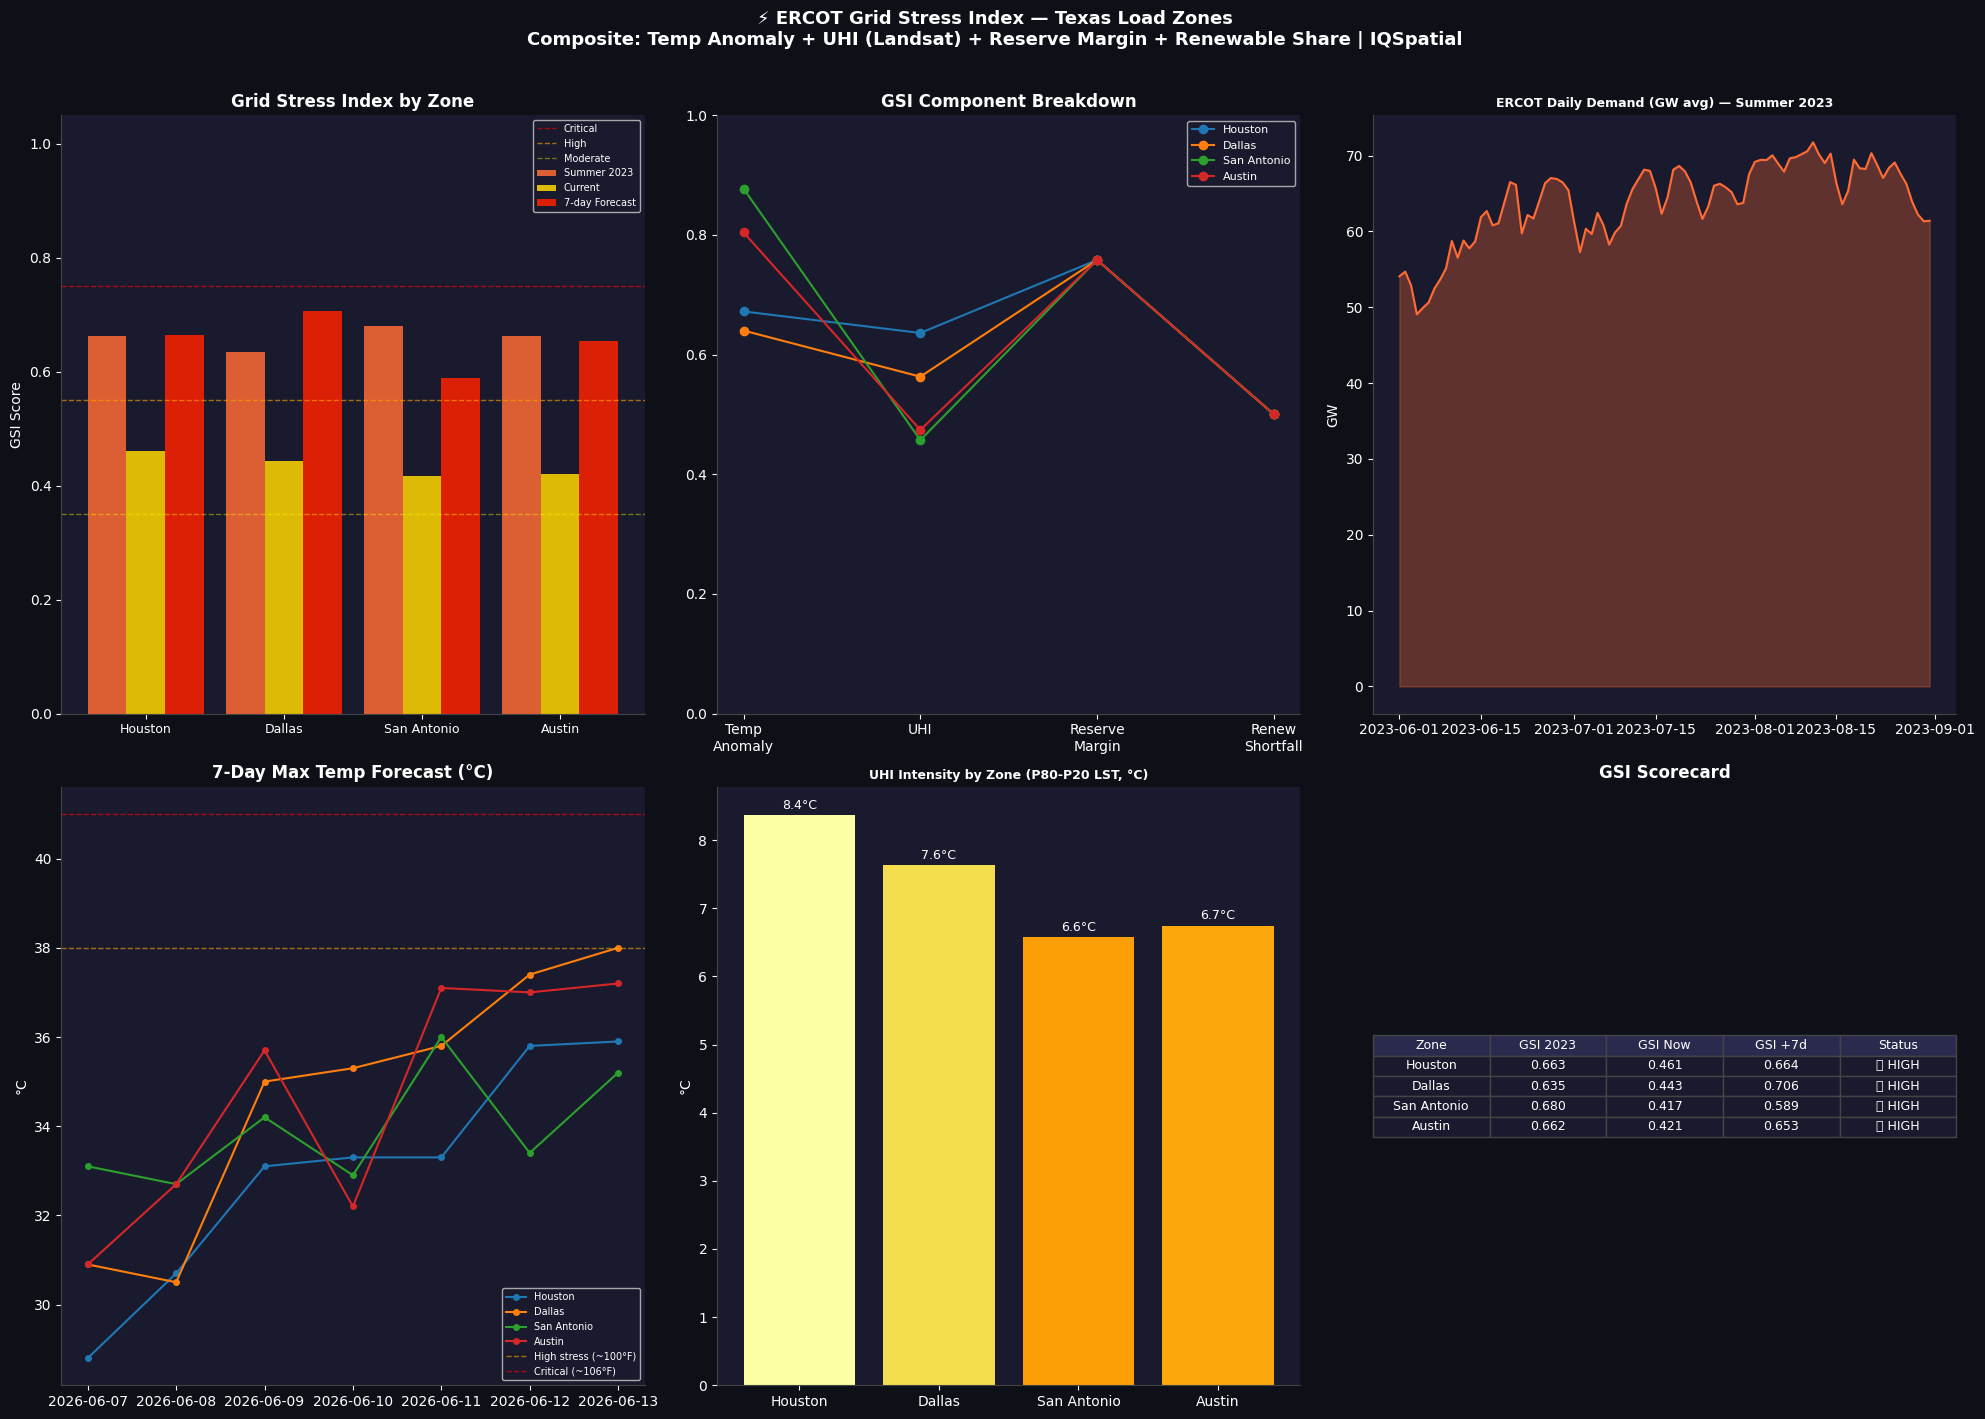

✅ Saved ercot_gsi.png


In [20]:
# Cell 11 — Visualization: GSI dashboard
fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#0d1117')

zones     = list(gsi_results.keys())
gsi_hist  = [gsi_results[z]['gsi_historical'] for z in zones]
gsi_curr  = [gsi_results[z]['gsi_current']    for z in zones]
gsi_fore  = [gsi_results[z]['gsi_forecast']   for z in zones]

# Panel 1: GSI bar comparison
ax1 = fig.add_subplot(2, 3, 1)
ax1.set_facecolor('#1a1a2e')
x = np.arange(len(zones))
w = 0.28
bars1 = ax1.bar(x - w, gsi_hist, w, label='Summer 2023', color='#ff6b35', alpha=0.85)
bars2 = ax1.bar(x,     gsi_curr, w, label='Current',     color='#ffd700', alpha=0.85)
bars3 = ax1.bar(x + w, gsi_fore, w, label='7-day Forecast', color='#ff2200', alpha=0.85)
ax1.axhline(0.75, color='red',    lw=1, ls='--', alpha=0.6, label='Critical')
ax1.axhline(0.55, color='orange', lw=1, ls='--', alpha=0.6, label='High')
ax1.axhline(0.35, color='yellow', lw=1, ls='--', alpha=0.4, label='Moderate')
ax1.set_xticks(x); ax1.set_xticklabels(zones, color='white', fontsize=9)
ax1.set_ylabel('GSI Score', color='white')
ax1.set_title('Grid Stress Index by Zone', color='white', fontweight='bold')
ax1.set_ylim(0, 1.05)
ax1.tick_params(colors='white')
ax1.spines[['top','right']].set_visible(False)
ax1.spines[['bottom','left']].set_color('#444')
ax1.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=7)

# Panel 2: Component breakdown radar-style bar
ax2 = fig.add_subplot(2, 3, 2)
ax2.set_facecolor('#1a1a2e')
components = ['Temp\nAnomaly', 'UHI', 'Reserve\nMargin', 'Renew\nShortfall']
comp_keys  = ['temp_anomaly', 'uhi', 'reserve_margin', 'renew_shortfall']
colors_comp = ['#ff6b35', '#ffd700', '#ff2200', '#66cc66']
for i, (zone, r) in enumerate(gsi_results.items()):
    vals = [r['components'][k] for k in comp_keys]
    ax2.plot(components, vals, marker='o', label=zone, linewidth=1.5)
ax2.set_ylim(0, 1)
ax2.set_title('GSI Component Breakdown', color='white', fontweight='bold')
ax2.tick_params(colors='white')
ax2.spines[['top','right']].set_visible(False)
ax2.spines[['bottom','left']].set_color('#444')
ax2.set_facecolor('#1a1a2e')
ax2.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=8)

# Panel 3: ERCOT demand time series (if available)
ax3 = fig.add_subplot(2, 3, 3)
ax3.set_facecolor('#1a1a2e')
if demand_df is not None:
    daily_demand = demand_df.set_index('datetime').resample('D')['demand_mwh'].mean() / 1000
    ax3.plot(daily_demand.index, daily_demand.values, color='#ff6b35', lw=1.5)
    ax3.fill_between(daily_demand.index, daily_demand.values, alpha=0.3, color='#ff6b35')
    ax3.set_title('ERCOT Daily Demand (GW avg) — Summer 2023', color='white', fontweight='bold', fontsize=9)
else:
    ax3.text(0.5, 0.5, 'EIA data unavailable\n(check API key)', ha='center', va='center',
             color='#888', transform=ax3.transAxes, fontsize=10)
    ax3.set_title('ERCOT Demand', color='white', fontweight='bold')
ax3.tick_params(colors='white')
ax3.spines[['top','right']].set_visible(False)
ax3.spines[['bottom','left']].set_color('#444')
ax3.set_ylabel('GW', color='white')

# Panel 4: 7-day temp forecast per zone
ax4 = fig.add_subplot(2, 3, 4)
ax4.set_facecolor('#1a1a2e')
for zone, curr in current.items():
    if curr:
        dates = pd.to_datetime(curr['forecast_dates'])
        ax4.plot(dates, curr['forecast_max_c'], marker='o', markersize=4,
                 label=zone, linewidth=1.5)
ax4.axhline(38, color='orange', lw=1, ls='--', alpha=0.6, label='High stress (~100°F)')
ax4.axhline(41, color='red',    lw=1, ls='--', alpha=0.6, label='Critical (~106°F)')
ax4.set_title('7-Day Max Temp Forecast (°C)', color='white', fontweight='bold')
ax4.tick_params(colors='white')
ax4.spines[['top','right']].set_visible(False)
ax4.spines[['bottom','left']].set_color('#444')
ax4.set_ylabel('°C', color='white')
ax4.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=7)

# Panel 5: UHI intensity by zone
ax5 = fig.add_subplot(2, 3, 5)
ax5.set_facecolor('#1a1a2e')
uhi_vals  = [gsi_results[z]['raw']['uhi_intensity_c'] or 0 for z in zones]
lst_vals  = [gsi_results[z]['raw']['mean_lst_c'] or 0 for z in zones]
bar_colors = [plt.cm.inferno(v/max(uhi_vals+[1])) for v in uhi_vals]
ax5.bar(zones, uhi_vals, color=bar_colors, edgecolor='none')
ax5.set_title('UHI Intensity by Zone (P80-P20 LST, °C)', color='white', fontweight='bold', fontsize=9)
ax5.tick_params(colors='white')
ax5.spines[['top','right']].set_visible(False)
ax5.spines[['bottom','left']].set_color('#444')
ax5.set_ylabel('°C', color='white')
for i, v in enumerate(uhi_vals):
    ax5.text(i, v + 0.1, f'{v:.1f}°C', ha='center', color='white', fontsize=9)

# Panel 6: GSI scorecard table
ax6 = fig.add_subplot(2, 3, 6)
ax6.set_facecolor('#1a1a2e')
ax6.axis('off')
table_data = []
for zone, r in gsi_results.items():
    table_data.append([
        zone,
        f"{r['gsi_historical']:.3f}",
        f"{r['gsi_current']:.3f}",
        f"{r['gsi_forecast']:.3f}",
        f"{r['icon_fore']} {r['level_fore']}"
    ])
tbl = ax6.table(
    cellText=table_data,
    colLabels=['Zone', 'GSI 2023', 'GSI Now', 'GSI +7d', 'Status'],
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
for (row, col), cell in tbl.get_celld().items():
    cell.set_facecolor('#1a1a2e' if row > 0 else '#2a2a4e')
    cell.set_text_props(color='white')
    cell.set_edgecolor('#444')
ax6.set_title('GSI Scorecard', color='white', fontweight='bold')

fig.suptitle('⚡ ERCOT Grid Stress Index — Texas Load Zones\n'
             'Composite: Temp Anomaly + UHI (Landsat) + Reserve Margin + Renewable Share | IQSpatial',
             color='white', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('ercot_gsi.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('✅ Saved ercot_gsi.png')

In [21]:
# Cell 12 — Interactive Folium map
m = folium.Map(location=[30.5, -97.5], zoom_start=6, tiles='CartoDB dark_matter')

def gsi_color(g):
    if g >= 0.75: return '#ff0000'
    elif g >= 0.55: return '#ff6600'
    elif g >= 0.35: return '#ffdd00'
    else:           return '#66cc66'

for zone, r in gsi_results.items():
    lat = r['meta']['center'][0]
    lon = r['meta']['center'][1]
    gsi_f = r['gsi_forecast']
    raw   = r['raw']
    comp  = r['components']

    popup_html = f"""
    <div style='font-family:monospace;font-size:11px;width:260px'>
    <b>⚡ ERCOT — {zone}</b><hr style='margin:3px 0'>
    <b>Grid Stress Index</b><br>
    Historical (2023): {r['gsi_historical']:.3f} {r['icon_hist']} {r['level_hist']}<br>
    Current:           {r['gsi_current']:.3f} {r['icon_curr']} {r['level_curr']}<br>
    7-day Forecast:    {r['gsi_forecast']:.3f} {r['icon_fore']} {r['level_fore']}<br>
    <hr style='margin:3px 0'>
    <b>Components</b><br>
    Temp Anomaly:    {comp['temp_anomaly']:.2f} (raw: {raw['temp_anomaly_c']:+.1f}°C)<br>
    UHI Intensity:   {comp['uhi']:.2f} ({raw['uhi_intensity_c']:.1f}°C spread)<br>
    Reserve Margin:  {comp['reserve_margin']:.2f}<br>
    Renew Shortfall: {comp['renew_shortfall']:.2f}<br>
    <hr style='margin:3px 0'>
    Current Temp: {raw['current_temp_c']:.1f}°C<br>
    7-day Max:    {raw['forecast_max_c']:.1f}°C<br>
    Mean LST:     {raw['mean_lst_c']:.1f}°C<br>
    <small style='color:gray'>{r['meta']['notes']}</small>
    </div>"""

    folium.CircleMarker(
        location=[lat, lon],
        radius=30 + gsi_f * 20,
        color=gsi_color(gsi_f),
        fill=True, fill_opacity=0.75,
        popup=folium.Popup(popup_html, max_width=280),
        tooltip=f"{zone} | GSI={gsi_f:.3f} | {r['level_fore']}"
    ).add_to(m)

    folium.Marker(
        location=[lat + 0.15, lon],
        icon=folium.DivIcon(
            html=f'<div style="font-size:9px;color:white;font-weight:bold;white-space:nowrap;">'
                 f'{zone} | GSI {gsi_f:.2f}</div>',
            icon_size=(180, 20), icon_anchor=(90, 10)
        )
    ).add_to(m)

m.save('ercot_gsi_map.html')
print('✅ Map saved to ercot_gsi_map.html')
m

✅ Map saved to ercot_gsi_map.html


In [23]:
# Cell 13 — LLM demand response advisory
OLLAMA_URL   = 'https://ollama.com/v1/chat/completions'
OLLAMA_MODEL = 'gpt-oss:20b'
OLLAMA_KEY   = 'vvvvvv'

SYSTEM_PROMPT = """You are a Senior Grid Operations Analyst and Demand Response Program Manager
at a large Texas electric utility. You hold a Certified Energy Manager (CEM) credential
and have 15+ years of experience managing ERCOT market operations and demand response programs.
You write operational advisories for a utility control room and DR program dispatch team.
Your language is direct, operational, and time-sensitive. You reference ERCOT protocols,
demand response triggers, ancillary services markets, and conservation voltage reduction (CVR).
Always lead with the highest-priority action item. Use MW and GW, not percentages alone.
Reference specific ERCOT emergency alert levels: Watch, Warning, Emergency Notice, EEA 1/2/3."""

zone_summaries = '\n'.join([
    f"""  {zone}:
    GSI={r['gsi_forecast']:.3f} ({r['level_fore']}) | Forecast max: {r['raw']['forecast_max_c']:.1f}°C
    Temp anomaly: {r['raw']['temp_anomaly_c']:+.1f}°C vs normal | UHI: {r['raw']['uhi_intensity_c']:.1f}°C spread
    Mean LST: {r['raw']['mean_lst_c']:.1f}°C | ERCOT zone: {r['meta']['ercot_zone']}"""
    for zone, r in gsi_results.items()
])

reserve_summary = ''
if reserves is not None:
    reserve_summary = f"""
ERCOT GRID STATUS (Summer 2023 context):
- Min reserve margin observed: {reserves['reserve_margin'].min():.1%}
- Mean reserve margin: {reserves['reserve_margin'].mean():.1%}
- ERCOT target reserve: 13.75%
- Mean renewable share: {renew_share:.1%}"""

prompt = f"""Prepare an operational Grid Stress Advisory and Demand Response Dispatch Recommendation.

SYSTEM: ERCOT Grid Stress Index (GSI) — Composite satellite + weather + grid signal
GSI COMPONENTS: Temperature anomaly (30%) + UHI satellite (25%) + Reserve margin (30%) + Renewable shortfall (15%)
GSI SCALE: 0.0-0.35=Low | 0.35-0.55=Moderate | 0.55-0.75=High | 0.75+=Critical

LOAD ZONE READINGS:
{zone_summaries}
{reserve_summary}

Provide your advisory in this format:

ERCOT GRID STRESS ADVISORY
Issued by: IQSpatial Grid Intelligence | GSI System v1.0
Coverage: ERCOT Houston / North / South Load Zones

1. OPERATIONAL SUMMARY (2-3 sentences — current grid stress posture and primary risk)

2. ZONE-BY-ZONE RISK ASSESSMENT
   For each zone: stress level, primary driver, estimated demand MW at risk

3. DEMAND RESPONSE DISPATCH RECOMMENDATION
   - Which DR programs to activate and in what order (interruptible load, emergency response, etc.)
   - Estimated MW available from DR dispatch
   - Recommended activation timeline relative to peak (T-4h, T-2h, T-1h triggers)
   - Conservation voltage reduction (CVR) recommendation

4. ERCOT ALERT LEVEL RECOMMENDATION
   - Current posture: Watch / Warning / Emergency Notice / EEA 1 / EEA 2 / EEA 3
   - Trigger conditions for escalation

5. SATELLITE INTELLIGENCE NOTE
   - How UHI and LST data from Landsat TIRS is informing this advisory
   - Which zones have elevated thermal mass that will sustain evening load longer

6. 7-DAY OUTLOOK
   - Forecast stress trajectory
   - Pre-positioning recommendations for DR program managers"""

resp = requests.post(
    OLLAMA_URL,
    headers={'Authorization': f'Bearer {OLLAMA_KEY}'},
    json={
        'model': OLLAMA_MODEL,
        'messages': [
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user',   'content': prompt}
        ],
        'temperature': 0.2
    },
    timeout=120
)
resp.raise_for_status()
print(resp.json()['choices'][0]['message']['content'])

We need to produce the advisory. Use the format. Provide operational summary, zone-by-zone risk assessment, DR dispatch recommendation, alert level recommendation, satellite intelligence note, 7-day outlook. Use MW numbers. We have GSI values and reserve margin. We need to estimate demand MW at risk. We can approximate based on typical load. For Houston, maybe 20 GW? But we can estimate risk based on GSI. Use high risk. Provide DR programs: interruptible load, emergency response, etc. Provide MW available. Use typical DR program capacities: e.g., 500 MW interruptible, 200 MW emergency. Provide timeline: T-4h, T-2h, T-1h. CVR: reduce voltage by 2% to cut load by ~2%. Provide alert level: likely Warning or Emergency Notice. Reserve margin is -45.8% min, mean -0.3%. So critical. So maybe EEA 1. Provide trigger conditions: reserve margin <5%, GSI >0.55, etc.

Satellite note: UHI and LST data show high thermal mass in San Antonio and Austin. Provide that.

7-day outlook: forecast GSI trendi

In [24]:
# Cell 14 — Summary printout (copy into LinkedIn post)
print('=' * 65)
print('ERCOT GRID STRESS INDEX — IQSpatial')
print('Composite: Temp Anomaly + UHI (Landsat) + Reserve Margin + Renewable Share')
print('=' * 65)
for zone, r in gsi_results.items():
    raw  = r['raw']
    comp = r['components']
    print(f'\n{zone.upper()} ({r["meta"]["ercot_zone"]} zone)')
    print(f'  GSI Historical (2023) : {r["gsi_historical"]:.3f} {r["icon_hist"]} {r["level_hist"]}')
    print(f'  GSI Current           : {r["gsi_current"]:.3f} {r["icon_curr"]} {r["level_curr"]}')
    print(f'  GSI 7-day Forecast    : {r["gsi_forecast"]:.3f} {r["icon_fore"]} {r["level_fore"]}')
    print(f'  Temp anomaly          : {raw["temp_anomaly_c"]:+.1f}°C vs 30yr normal')
    print(f'  UHI intensity         : {raw["uhi_intensity_c"]:.1f}°C (Landsat P80-P20)')
    print(f'  Mean LST              : {raw["mean_lst_c"]:.1f}°C')
    print(f'  Current temp          : {raw["current_temp_c"]:.1f}°C')
    print(f'  7-day forecast max    : {raw["forecast_max_c"]:.1f}°C')
print('\n' + '=' * 65)
print('Data: Open-Meteo · Landsat TIRS · EIA API · ERCOT')
print('Code: github.com/rmkenv | Analysis: IQSpatial (@rmkenv)')
print('=' * 65)

ERCOT GRID STRESS INDEX — IQSpatial
Composite: Temp Anomaly + UHI (Landsat) + Reserve Margin + Renewable Share

HOUSTON (HOUSTON zone)
  GSI Historical (2023) : 0.663 🟠 HIGH
  GSI Current           : 0.461 🟡 MODERATE
  GSI 7-day Forecast    : 0.664 🟠 HIGH
  Temp anomaly          : +2.7°C vs 30yr normal
  UHI intensity         : 8.4°C (Landsat P80-P20)
  Mean LST              : 44.7°C
  Current temp          : 26.5°C
  7-day forecast max    : 35.9°C

DALLAS (NORTH zone)
  GSI Historical (2023) : 0.635 🟠 HIGH
  GSI Current           : 0.443 🟡 MODERATE
  GSI 7-day Forecast    : 0.706 🟠 HIGH
  Temp anomaly          : +2.5°C vs 30yr normal
  UHI intensity         : 7.6°C (Landsat P80-P20)
  Mean LST              : 48.9°C
  Current temp          : 22.6°C
  7-day forecast max    : 38.0°C

SAN ANTONIO (SOUTH zone)
  GSI Historical (2023) : 0.680 🟠 HIGH
  GSI Current           : 0.417 🟡 MODERATE
  GSI 7-day Forecast    : 0.589 🟠 HIGH
  Temp anomaly          : +4.1°C vs 30yr normal
  UHI intensi